# ニュースを用いたテーマバスケット相対魅力度モデル

このノートブックは、添付 YAML のようなテーマ定義を入力として、以下を Jupyter 内で完結して実行します。

1. テーマ定義・収益ドライバー定義の読み込み
2. ニュース記事のテーマ・ドライバー分類
3. attention / sentiment / novelty / breadth / risk / underreaction の日次特徴量化
4. テーマリターンのファクター残差化
5. ルールベーススコア + walk-forward ML スコアの作成
6. テーマ間リスク・重複・売買回転を考慮した配分
7. バックテスト、ランキング、エクスポート

実データがない環境でも動作確認できるよう、サンプルニュース、サンプル構成銘柄、サンプルリターンを生成します。実運用では、該当セルの `news_df`、`holdings_df`、`theme_returns_df`、`factor_returns_df`、`valuation_df` を実データに差し替えてください。

In [1]:
# ============================================================
# 0. Imports and global configuration
# ============================================================
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple, Any
import math
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import yaml

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import matplotlib.pyplot as plt

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

## 1. テーマ定義 YAML の読み込み

同じディレクトリに `theme_profiles 2.yaml` があればそれを読み込みます。なければ、このノートブックに埋め込んだ添付 YAML を使います。

In [2]:
# ============================================================
# 1. Load theme YAML
# ============================================================
EMBEDDED_THEME_YAML = 'themes:\n  - theme_id: semiconductor_equipment_jp\n    theme_name_en: Japanese Semiconductor Equipment\n    theme_name_ja: 半導体製造装置\n    theme_type: industry_theme\n    description_en: >\n      Japanese semiconductor equipment companies exposed to wafer fabrication equipment demand,\n      AI semiconductor capex, memory cycle, foundry investment, and export controls.\n    description_ja: >\n      半導体製造装置、検査装置、AI半導体設備投資、メモリ市況、ファウンドリー投資、輸出規制の影響を受ける日本株テーマ。\n    profile_summary_en: >\n      Exposure to semiconductor equipment orders, foundry capex, AI semiconductor demand, and memory cycle recovery.\n    profile_summary_ja: >\n      半導体製造装置受注、ファウンドリー投資、AI半導体需要、メモリ市況回復に連動するテーマ。\n    revenue_drivers:\n      - driver_id: semiconductor_equipment_jp__driver_001\n        driver_name_en: Semiconductor capital expenditure cycle\n        driver_name_ja: 半導体設備投資サイクル\n        driver_type: capex_driver\n        driver_description_en: Global wafer fab investment and capacity expansion drive semiconductor equipment demand.\n        driver_description_ja: グローバルな半導体工場投資と生産能力増強が製造装置需要を左右する。\n        driver_embedding_text: >\n          Semiconductor capital expenditure cycle. 半導体設備投資サイクル。Wafer fab investment, foundry capex,\n          semiconductor equipment orders, AI semiconductor investment, 半導体製造装置受注、ファウンドリー投資、AI半導体設備投資。\n        driver_keywords_en: [semiconductor capex, wafer fab investment, foundry capex, chip equipment orders]\n        driver_keywords_ja: [半導体設備投資, 半導体製造装置受注, ファウンドリー投資, AI半導体投資]\n        positive_driver_events_en: [capex increase, order recovery, foundry investment expansion]\n        positive_driver_events_ja: [設備投資増額, 受注回復, ファウンドリー投資拡大]\n        negative_driver_events_en: [capex cut, order decline, investment delay]\n        negative_driver_events_ja: [設備投資削減, 受注減少, 投資延期]\n      - driver_id: semiconductor_equipment_jp__driver_002\n        driver_name_en: AI semiconductor demand\n        driver_name_ja: AI半導体需要\n        driver_type: demand_driver\n        driver_description_en: AI accelerators and data center demand support semiconductor production equipment demand.\n        driver_description_ja: AIアクセラレーターやデータセンター需要が半導体製造装置需要を支える。\n        driver_embedding_text: >\n          AI semiconductor demand. AI半導体需要。AI accelerator, GPU demand, data center capex, HBM, advanced packaging,\n          AIサーバー、GPU需要、データセンター設備投資、先端パッケージ。\n        driver_keywords_en: [AI semiconductor, GPU demand, AI accelerator, data center capex, HBM]\n        driver_keywords_ja: [AI半導体, GPU需要, AIアクセラレーター, データセンター投資, HBM]\n        positive_driver_events_en: [AI server demand increase, hyperscaler capex increase]\n        positive_driver_events_ja: [AIサーバー需要増加, ハイパースケーラー投資増額]\n        negative_driver_events_en: [AI capex slowdown, export restriction]\n        negative_driver_events_ja: [AI投資減速, 輸出規制]\n    catalysts_en: [semiconductor equipment, chip equipment, AI semiconductor, memory recovery, foundry capex, export controls]\n    catalysts_ja: [半導体製造装置, AI半導体, メモリ市況, ファウンドリー投資, 設備投資, 輸出規制]\n    positive_events_en: [order increase, capex increase, upward guidance, memory price recovery]\n    positive_events_ja: [受注増加, 設備投資増額, 上方修正, メモリ価格回復]\n    negative_events_en: [export restrictions, order decline, capex delay, guidance cut]\n    negative_events_ja: [輸出規制, 受注減少, 設備投資延期, 下方修正]\n    related_macro_factors_en: [semiconductor cycle, USDJPY, global capex cycle]\n    related_macro_factors_ja: [半導体サイクル, 米ドル円, グローバル設備投資サイクル]\n    related_policy_factors_en: [export controls, economic security, semiconductor subsidy]\n    related_policy_factors_ja: [輸出規制, 経済安全保障, 半導体補助金]\n    related_industries:\n      gics_sectors: [Information Technology]\n      gics_industries: [Semiconductors & Semiconductor Equipment]\n      trbc_industries: [Semiconductor Equipment]\n    keyword_match_terms_en: [semiconductor capex, wafer fab, foundry capex, chip equipment, AI semiconductor, export controls]\n    keyword_match_terms_ja: [半導体設備投資, 半導体製造装置, ファウンドリー投資, AI半導体, 輸出規制]\n    embedding_text: >\n      Japanese Semiconductor Equipment 半導体製造装置。半導体設備投資サイクル、AI半導体需要、メモリ市況、ファウンドリー投資、輸出規制に関する日本株テーマ。\n      News about wafer fab investment, foundry capex, chip equipment orders, AI semiconductor demand, HBM and export controls is relevant.\n    entity_linking_terms:\n      rics: [8035.T, 6857.T]\n      company_names_en: [Tokyo Electron, Advantest]\n      company_names_ja: [東京エレクトロン, アドバンテスト]\n      aliases_en: [TEL]\n      aliases_ja: [東エレク]\n    notes_for_classification: >\n      個別企業名が出ないニュースでも、半導体設備投資、AI半導体、ファウンドリー投資、輸出規制に関するニュースは関連度を高く評価する。\n\n  - theme_id: low_pbr_reform_jp\n    theme_name_en: Low PBR and Capital Efficiency Reform Japan\n    theme_name_ja: 低PBR・資本効率改革\n    theme_type: style_theme\n    description_en: >\n      Japanese equities exposed to low price-to-book valuation, capital efficiency reform, shareholder returns,\n      buybacks, dividend hikes, governance reform, and activist pressure.\n    description_ja: >\n      PBR1倍割れ、資本効率改善、株主還元強化、東証要請、自社株買い、増配、ガバナンス改革に関連する日本株テーマ。\n    profile_summary_en: Exposure to capital efficiency improvement, shareholder returns, governance reform, and valuation re-rating in Japan.\n    profile_summary_ja: 資本効率改善、株主還元、ガバナンス改革、割安修正に連動する日本株テーマ。\n    revenue_drivers:\n      - driver_id: low_pbr_reform_jp__driver_001\n        driver_name_en: Capital efficiency reform\n        driver_name_ja: 資本効率改革\n        driver_type: valuation_driver\n        driver_description_en: Corporate actions to improve ROE, cost of capital awareness, and price-to-book valuation.\n        driver_description_ja: ROE改善、資本コスト意識、PBR改善に向けた企業行動がテーマのドライバーとなる。\n        driver_embedding_text: >\n          Capital efficiency reform. 資本効率改革。PBR below one, return on equity, cost of capital, TSE reform,\n          governance reform, PBR1倍割れ、ROE改善、資本コスト、東証要請、ガバナンス改革。\n        driver_keywords_en: [PBR below one, capital efficiency, cost of capital, ROE improvement, Tokyo Stock Exchange reform]\n        driver_keywords_ja: [PBR1倍割れ, 資本効率, 資本コスト, ROE改善, 東証要請]\n        positive_driver_events_en: [ROE target increase, capital policy update, valuation re-rating]\n        positive_driver_events_ja: [ROE目標引き上げ, 資本政策変更, 割安修正]\n        negative_driver_events_en: [capital policy disappointment, governance controversy]\n        negative_driver_events_ja: [資本政策後退, ガバナンス不祥事]\n      - driver_id: low_pbr_reform_jp__driver_002\n        driver_name_en: Shareholder return improvement\n        driver_name_ja: 株主還元強化\n        driver_type: shareholder_return_driver\n        driver_description_en: Buybacks, dividend hikes, payout policy changes, and cross-shareholding reduction support shareholder returns.\n        driver_description_ja: 自社株買い、増配、配当方針変更、政策保有株縮減が株主還元強化につながる。\n        driver_embedding_text: >\n          Shareholder return improvement. 株主還元強化。Share buyback, dividend hike, payout ratio, cross-shareholding reduction,\n          自社株買い、増配、配当性向、政策保有株縮減。\n        driver_keywords_en: [share buyback, dividend hike, payout ratio, shareholder return, cross-shareholding reduction]\n        driver_keywords_ja: [自社株買い, 増配, 配当性向, 株主還元, 政策保有株縮減]\n        positive_driver_events_en: [buyback announcement, dividend increase, cross-shareholding sale]\n        positive_driver_events_ja: [自社株買い発表, 増配, 政策保有株売却]\n        negative_driver_events_en: [dividend cut, equity offering]\n        negative_driver_events_ja: [減配, 公募増資]\n    catalysts_en: [PBR below one, capital efficiency, share buyback, dividend increase, activist investor, governance reform]\n    catalysts_ja: [PBR1倍割れ, 資本効率, 自社株買い, 増配, アクティビスト, ガバナンス改革]\n    positive_events_en: [buyback announcement, dividend hike, capital policy update, activist stake disclosure]\n    positive_events_ja: [自社株買い発表, 増配, 資本政策変更, アクティビスト保有判明]\n    negative_events_en: [dividend cut, equity offering, governance controversy, earnings downgrade]\n    negative_events_ja: [減配, 公募増資, ガバナンス不祥事, 下方修正]\n    related_macro_factors_en: [Japan equity risk appetite, interest rates]\n    related_macro_factors_ja: [日本株リスク選好, 金利]\n    related_policy_factors_en: [Tokyo Stock Exchange capital efficiency request, governance code]\n    related_policy_factors_ja: [東証による資本効率改善要請, コーポレートガバナンス・コード]\n    related_industries:\n      gics_sectors: []\n      gics_industries: []\n      trbc_industries: []\n    keyword_match_terms_en: [PBR below one, price-to-book, capital efficiency, cost of capital, share buyback, dividend hike, activist]\n    keyword_match_terms_ja: [PBR1倍割れ, 資本効率, 資本コスト, 自社株買い, 増配, 株主還元, アクティビスト]\n    embedding_text: >\n      Low PBR and capital efficiency reform 低PBR・資本効率改革。PBR1倍割れ、資本効率、ROE改善、資本コスト、東証要請、自社株買い、増配、株主還元、政策保有株縮減に関する日本株テーマ。\n    entity_linking_terms:\n      rics: []\n      company_names_en: []\n      company_names_ja: []\n      aliases_en: []\n      aliases_ja: []\n    notes_for_classification: >\n      個別企業名がないニュースでも、PBR、資本効率、自社株買い、増配、東証要請に関するニュースは高く評価する。\n'

candidate_paths = [
    Path('theme_profiles 2.yaml'),
    Path('/mnt/data/theme_profiles 2.yaml'),
]

for p in candidate_paths:
    if p.exists():
        THEME_YAML_PATH = p
        break
else:
    THEME_YAML_PATH = None

if THEME_YAML_PATH is not None:
    theme_yaml_text = THEME_YAML_PATH.read_text(encoding='utf-8')
    print(f'Loaded YAML from: {THEME_YAML_PATH}')
else:
    theme_yaml_text = EMBEDDED_THEME_YAML
    print('Loaded YAML from embedded fallback.')

theme_config = yaml.safe_load(theme_yaml_text)
print(f"Number of themes: {len(theme_config.get('themes', []))}")

Loaded YAML from: theme_profiles 2.yaml
Number of themes: 2


In [3]:
# ============================================================
# 2. Theme parser utilities
# ============================================================
def safe_list(x: Any) -> List[str]:
    if x is None:
        return []
    if isinstance(x, list):
        return [str(v) for v in x if v is not None and str(v).strip() != '']
    if isinstance(x, tuple):
        return [str(v) for v in x if v is not None and str(v).strip() != '']
    if isinstance(x, str):
        return [x] if x.strip() else []
    return [str(x)]


def normalize_text(x: Any) -> str:
    """Japanese/English mixed text normalization for phrase and char-ngram matching."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return ''
    s = unicodedata.normalize('NFKC', str(x)).lower()
    s = re.sub(r'\s+', ' ', s).strip()
    return s


def list_join(xs: Iterable[str]) -> str:
    return ' '.join([str(x) for x in xs if x is not None])


def parse_theme_profiles(config: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    theme_rows = []
    driver_rows = []
    for t in config.get('themes', []):
        ent = t.get('entity_linking_terms', {}) or {}
        theme_keywords = []
        for key in [
            'catalysts_en', 'catalysts_ja',
            'keyword_match_terms_en', 'keyword_match_terms_ja',
            'related_macro_factors_en', 'related_macro_factors_ja',
            'related_policy_factors_en', 'related_policy_factors_ja',
        ]:
            theme_keywords += safe_list(t.get(key))
        entity_terms = []
        for key in ['rics', 'company_names_en', 'company_names_ja', 'aliases_en', 'aliases_ja']:
            entity_terms += safe_list(ent.get(key))
        theme_rows.append({
            'theme_id': t.get('theme_id'),
            'theme_name_en': t.get('theme_name_en', ''),
            'theme_name_ja': t.get('theme_name_ja', ''),
            'theme_type': t.get('theme_type', ''),
            'description_en': t.get('description_en', ''),
            'description_ja': t.get('description_ja', ''),
            'profile_summary_en': t.get('profile_summary_en', ''),
            'profile_summary_ja': t.get('profile_summary_ja', ''),
            'embedding_text': t.get('embedding_text', ''),
            'theme_keywords': sorted(set(theme_keywords)),
            'positive_events': sorted(set(safe_list(t.get('positive_events_en')) + safe_list(t.get('positive_events_ja')))),
            'negative_events': sorted(set(safe_list(t.get('negative_events_en')) + safe_list(t.get('negative_events_ja')))),
            'entity_terms': sorted(set(entity_terms)),
            'rics': safe_list(ent.get('rics')),
            'company_names_en': safe_list(ent.get('company_names_en')),
            'company_names_ja': safe_list(ent.get('company_names_ja')),
            'aliases_en': safe_list(ent.get('aliases_en')),
            'aliases_ja': safe_list(ent.get('aliases_ja')),
            'notes_for_classification': t.get('notes_for_classification', ''),
        })
        for d in t.get('revenue_drivers', []) or []:
            driver_rows.append({
                'theme_id': t.get('theme_id'),
                'driver_id': d.get('driver_id'),
                'driver_name_en': d.get('driver_name_en', ''),
                'driver_name_ja': d.get('driver_name_ja', ''),
                'driver_type': d.get('driver_type', ''),
                'driver_description_en': d.get('driver_description_en', ''),
                'driver_description_ja': d.get('driver_description_ja', ''),
                'driver_embedding_text': d.get('driver_embedding_text', ''),
                'driver_keywords': sorted(set(
                    safe_list(d.get('driver_keywords_en')) + safe_list(d.get('driver_keywords_ja'))
                )),
                'positive_driver_events': sorted(set(
                    safe_list(d.get('positive_driver_events_en')) + safe_list(d.get('positive_driver_events_ja'))
                )),
                'negative_driver_events': sorted(set(
                    safe_list(d.get('negative_driver_events_en')) + safe_list(d.get('negative_driver_events_ja'))
                )),
            })
    theme_df = pd.DataFrame(theme_rows)
    driver_df = pd.DataFrame(driver_rows)
    theme_df['theme_corpus'] = (
        theme_df['theme_name_en'].fillna('') + ' ' + theme_df['theme_name_ja'].fillna('') + ' ' +
        theme_df['description_en'].fillna('') + ' ' + theme_df['description_ja'].fillna('') + ' ' +
        theme_df['profile_summary_en'].fillna('') + ' ' + theme_df['profile_summary_ja'].fillna('') + ' ' +
        theme_df['embedding_text'].fillna('') + ' ' + theme_df['theme_keywords'].map(list_join)
    ).map(normalize_text)
    driver_df['driver_corpus'] = (
        driver_df['driver_name_en'].fillna('') + ' ' + driver_df['driver_name_ja'].fillna('') + ' ' +
        driver_df['driver_description_en'].fillna('') + ' ' + driver_df['driver_description_ja'].fillna('') + ' ' +
        driver_df['driver_embedding_text'].fillna('') + ' ' + driver_df['driver_keywords'].map(list_join)
    ).map(normalize_text)
    return theme_df, driver_df


theme_df, driver_df = parse_theme_profiles(theme_config)
theme_df[['theme_id', 'theme_name_ja', 'theme_type', 'theme_keywords', 'entity_terms']]

,theme_id,theme_name_ja,theme_type,theme_keywords,entity_terms
0,semiconductor_equipment_jp,半導体製造装置,industry_theme,"[AI semiconductor, AI半導体, USDJPY, chip equipme...","[6857.T, 8035.T, Advantest, TEL, Tokyo Electro..."
1,low_pbr_reform_jp,低PBR・資本効率改革,style_theme,"[Japan equity risk appetite, PBR below one, PB...",[]


In [4]:
driver_df[['theme_id', 'driver_id', 'driver_name_ja', 'driver_type', 'driver_keywords', 'positive_driver_events', 'negative_driver_events']]

,theme_id,driver_id,driver_name_ja,driver_type,driver_keywords,positive_driver_events,negative_driver_events
0,semiconductor_equipment_jp,semiconductor_equipment_jp__driver_001,半導体設備投資サイクル,capex_driver,"[AI半導体投資, chip equipment orders, foundry capex...","[capex increase, foundry investment expansion,...","[capex cut, investment delay, order decline, 受..."
1,semiconductor_equipment_jp,semiconductor_equipment_jp__driver_002,AI半導体需要,demand_driver,"[AI accelerator, AI semiconductor, AIアクセラレーター,...","[AI server demand increase, AIサーバー需要増加, hypers...","[AI capex slowdown, AI投資減速, export restriction..."
2,low_pbr_reform_jp,low_pbr_reform_jp__driver_001,資本効率改革,valuation_driver,"[PBR below one, PBR1倍割れ, ROE improvement, ROE改...","[ROE target increase, ROE目標引き上げ, capital polic...","[capital policy disappointment, governance con..."
3,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,shareholder_return_driver,"[cross-shareholding reduction, dividend hike, ...","[buyback announcement, cross-shareholding sale...","[dividend cut, equity offering, 公募増資, 減配]"


## 2. 入力データの準備

実運用で差し替えるデータは、最低限以下です。

- `news_df`: `date`, `headline`, `body`, `source_type` を持つニュースデータ
- `holdings_df`: `theme_id`, `ticker`, `weight`, `company_name_ja`, `company_name_en`, `aliases` を持つ構成銘柄データ
- `theme_returns_df`: `date`, `theme_id`, `ret` を持つテーマバスケット日次リターン
- `factor_returns_df`: `date` と市場・スタイル・マクロファクター日次リターン
- `valuation_df`: `date`, `theme_id`, `valuation_penalty`, `crowding_penalty` など

ここではノートブック単体で動かすため、サンプルデータを生成します。

In [5]:
# ============================================================
# 3. Demo holdings
# ============================================================
def build_holdings_from_yaml(theme_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, t in theme_df.iterrows():
        rics = safe_list(t.get('rics'))
        names_en = safe_list(t.get('company_names_en'))
        names_ja = safe_list(t.get('company_names_ja'))
        aliases_en = safe_list(t.get('aliases_en'))
        aliases_ja = safe_list(t.get('aliases_ja'))
        n = max(len(rics), len(names_en), len(names_ja), 1)
        for i in range(n):
            if i < len(rics):
                rows.append({
                    'theme_id': t['theme_id'],
                    'ticker': rics[i],
                    'weight': 1.0 / max(len(rics), 1),
                    'company_name_en': names_en[i] if i < len(names_en) else '',
                    'company_name_ja': names_ja[i] if i < len(names_ja) else '',
                    'aliases': aliases_en + aliases_ja,
                    'source': 'yaml_entity_terms',
                })
    return pd.DataFrame(rows)

holdings_df = build_holdings_from_yaml(theme_df)

# Demo only: low PBR theme has no names in YAML, so add illustrative constituents.
# Replace this block with real point-in-time holdings in production.
demo_low_pbr_holdings = pd.DataFrame([
    {'theme_id': 'low_pbr_reform_jp', 'ticker': '8306.T', 'weight': 0.30, 'company_name_en': 'Mitsubishi UFJ Financial Group', 'company_name_ja': '三菱UFJフィナンシャル・グループ', 'aliases': ['MUFG', '三菱UFJ'], 'source': 'demo'},
    {'theme_id': 'low_pbr_reform_jp', 'ticker': '8058.T', 'weight': 0.25, 'company_name_en': 'Mitsubishi Corporation', 'company_name_ja': '三菱商事', 'aliases': [], 'source': 'demo'},
    {'theme_id': 'low_pbr_reform_jp', 'ticker': '7203.T', 'weight': 0.25, 'company_name_en': 'Toyota Motor', 'company_name_ja': 'トヨタ自動車', 'aliases': ['トヨタ'], 'source': 'demo'},
    {'theme_id': 'low_pbr_reform_jp', 'ticker': '5401.T', 'weight': 0.20, 'company_name_en': 'Nippon Steel', 'company_name_ja': '日本製鉄', 'aliases': [], 'source': 'demo'},
])

holdings_df = pd.concat([holdings_df, demo_low_pbr_holdings], ignore_index=True)
holdings_df['weight'] = holdings_df.groupby('theme_id')['weight'].transform(lambda s: s / s.sum())
holdings_df

,theme_id,ticker,weight,company_name_en,company_name_ja,aliases,source
0,semiconductor_equipment_jp,8035.T,0.50,Tokyo Electron,東京エレクトロン,"[TEL, 東エレク]",yaml_entity_terms
1,semiconductor_equipment_jp,6857.T,0.50,Advantest,アドバンテスト,"[TEL, 東エレク]",yaml_entity_terms
2,low_pbr_reform_jp,8306.T,0.30,Mitsubishi UFJ Financial Group,三菱UFJフィナンシャル・グループ,"[MUFG, 三菱UFJ]",demo
3,low_pbr_reform_jp,8058.T,0.25,Mitsubishi Corporation,三菱商事,[],demo
4,low_pbr_reform_jp,7203.T,0.25,Toyota Motor,トヨタ自動車,[トヨタ],demo
5,low_pbr_reform_jp,5401.T,0.20,Nippon Steel,日本製鉄,[],demo


In [6]:
# ============================================================
# 4. Demo news generation
# ============================================================
def make_demo_news(start: str = '2025-01-02', periods: int = 180, seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, periods=periods)
    rows = []
    news_id = 0

    semicap_pos = [
        ('東京エレクトロン、AI半導体向け製造装置の受注回復を示唆', 'AIサーバー需要増加、HBM、先端パッケージ投資、ファウンドリー投資拡大が装置需要を支える。', 'major_media'),
        ('大手ファウンドリーが先端プロセスの設備投資増額を発表', 'Wafer fab investment and foundry capex expansion support Japanese semiconductor equipment orders.', 'wire'),
        ('アドバンテスト、GPU需要を背景に検査装置の上方修正観測', 'AI accelerator and GPU demand increase. Semiconductor equipment orders recover.', 'major_media'),
    ]
    semicap_neg = [
        ('米国の対中輸出規制強化で半導体製造装置に懸念', 'Export controls may delay semiconductor capex and chip equipment orders.', 'major_media'),
        ('メモリ市況の回復遅れ、装置投資の延期観測', 'Memory capex delay and order decline weigh on semiconductor equipment makers.', 'wire'),
    ]
    lowpbr_pos = [
        ('東証要請を受けPBR1倍割れ企業が資本政策を見直し', 'Capital efficiency reform, ROE improvement and cost of capital disclosure accelerate.', 'exchange'),
        ('三菱UFJ、自社株買いと増配を発表', 'Share buyback announcement and dividend hike improve shareholder returns.', 'company_disclosure'),
        ('アクティビスト保有判明、低PBR企業に株主還元強化圧力', 'Activist investor pushes governance reform and capital efficiency improvement.', 'major_media'),
        ('三菱商事、政策保有株の売却と株主還元方針を更新', 'Cross-shareholding reduction and payout policy update support valuation re-rating.', 'company_disclosure'),
    ]
    lowpbr_neg = [
        ('低PBR企業の公募増資発表に失望売り', 'Equity offering and capital policy disappointment reduce shareholder return expectations.', 'major_media'),
        ('一部企業でガバナンス不祥事、資本効率改革に逆風', 'Governance controversy raises uncertainty over capital efficiency reform.', 'wire'),
    ]
    noise = [
        ('国内消費関連株に物色、インバウンド需要が支え', 'Retail and travel names move higher on inbound tourism demand.', 'major_media'),
        ('原油価格が小幅上昇、エネルギー株に買い', 'Energy stocks rise as crude oil prices increase.', 'wire'),
        ('為替市場で円が対ドルで小動き', 'USDJPY trades in a narrow range with limited equity impact.', 'wire'),
    ]

    for i, dt in enumerate(dates):
        # Smooth trend regimes used only to create a richer demo sample.
        semicap_prob = 0.10 + 0.30 / (1.0 + np.exp(-(i - 55) / 14))
        lowpbr_prob = 0.12 + 0.25 / (1.0 + np.exp(-(i - 35) / 12)) - 0.10 / (1.0 + np.exp(-(i - 125) / 10))
        if rng.random() < semicap_prob:
            tpl = semicap_pos[int(rng.integers(len(semicap_pos)))]
            rows.append({'news_id': f'N{news_id:05d}', 'date': dt, 'headline': tpl[0], 'body': tpl[1], 'source_type': tpl[2]}); news_id += 1
        if rng.random() < 0.07:
            tpl = semicap_neg[int(rng.integers(len(semicap_neg)))]
            rows.append({'news_id': f'N{news_id:05d}', 'date': dt, 'headline': tpl[0], 'body': tpl[1], 'source_type': tpl[2]}); news_id += 1
        if rng.random() < max(lowpbr_prob, 0.02):
            tpl = lowpbr_pos[int(rng.integers(len(lowpbr_pos)))]
            rows.append({'news_id': f'N{news_id:05d}', 'date': dt, 'headline': tpl[0], 'body': tpl[1], 'source_type': tpl[2]}); news_id += 1
        if rng.random() < 0.06:
            tpl = lowpbr_neg[int(rng.integers(len(lowpbr_neg)))]
            rows.append({'news_id': f'N{news_id:05d}', 'date': dt, 'headline': tpl[0], 'body': tpl[1], 'source_type': tpl[2]}); news_id += 1
        if rng.random() < 0.25:
            tpl = noise[int(rng.integers(len(noise)))]
            rows.append({'news_id': f'N{news_id:05d}', 'date': dt, 'headline': tpl[0], 'body': tpl[1], 'source_type': tpl[2]}); news_id += 1
    df = pd.DataFrame(rows).sort_values(['date', 'news_id']).reset_index(drop=True)
    df['news_text'] = (df['headline'].fillna('') + '。' + df['body'].fillna('')).map(normalize_text)
    return df

news_df = make_demo_news()
print(news_df.shape)
news_df.head(10)

(181, 6)


,news_id,date,headline,body,source_type,news_text
0,N00000,2025-01-02,原油価格が小幅上昇、エネルギー株に買い,Energy stocks rise as crude oil prices increase.,wire,原油価格が小幅上昇、エネルギー株に買い。energy stocks rise as crud...
1,N00001,2025-01-03,三菱商事、政策保有株の売却と株主還元方針を更新,Cross-shareholding reduction and payout policy...,company_disclosure,三菱商事、政策保有株の売却と株主還元方針を更新。cross-shareholding red...
2,N00002,2025-01-06,国内消費関連株に物色、インバウンド需要が支え,Retail and travel names move higher on inbound...,major_media,国内消費関連株に物色、インバウンド需要が支え。retail and travel names...
3,N00003,2025-01-07,大手ファウンドリーが先端プロセスの設備投資増額を発表,Wafer fab investment and foundry capex expansi...,wire,大手ファウンドリーが先端プロセスの設備投資増額を発表。wafer fab investmen...
4,N00004,2025-01-09,大手ファウンドリーが先端プロセスの設備投資増額を発表,Wafer fab investment and foundry capex expansi...,wire,大手ファウンドリーが先端プロセスの設備投資増額を発表。wafer fab investmen...
5,N00005,2025-01-15,低PBR企業の公募増資発表に失望売り,Equity offering and capital policy disappointm...,major_media,低pbr企業の公募増資発表に失望売り。equity offering and capital...
6,N00006,2025-01-21,大手ファウンドリーが先端プロセスの設備投資増額を発表,Wafer fab investment and foundry capex expansi...,wire,大手ファウンドリーが先端プロセスの設備投資増額を発表。wafer fab investmen...
7,N00007,2025-01-21,原油価格が小幅上昇、エネルギー株に買い,Energy stocks rise as crude oil prices increase.,wire,原油価格が小幅上昇、エネルギー株に買い。energy stocks rise as crud...
8,N00008,2025-01-22,アドバンテスト、GPU需要を背景に検査装置の上方修正観測,AI accelerator and GPU demand increase. Semico...,major_media,アドバンテスト、gpu需要を背景に検査装置の上方修正観測。ai accelerator an...
9,N00009,2025-01-23,国内消費関連株に物色、インバウンド需要が支え,Retail and travel names move higher on inbound...,major_media,国内消費関連株に物色、インバウンド需要が支え。retail and travel names...


## 3. ニュース分類エンジン

このセルでは、LLM や外部 API を使わずに動く実装として、以下を併用します。

- char n-gram TF-IDF によるテーマ・ドライバー embedding 類似度
- YAML 内のキーワード・イベント語による phrase matching
- 構成銘柄・別名による entity linking
- positive / negative driver event による impact 推定
- rolling 類似度に基づく novelty 推定

実運用では、`TfidfVectorizer` 部分を金融ドメイン embedding、LLM reranker、あるいは sentence transformer に置き換えられます。

In [7]:
# ============================================================
# 5. News classification utilities
# ============================================================
GENERIC_POSITIVE_TERMS = [
    'increase', 'expansion', 'recovery', 'upgrade', 'upward', 'strong demand', 'improvement',
    'announcement', 'approved', 'confirmed', 'buyback', 'dividend hike', '受注回復', '受注増加',
    '拡大', '増額', '上方修正', '回復', '改善', '発表', '承認', '決定', '自社株買い', '増配'
]
GENERIC_NEGATIVE_TERMS = [
    'decline', 'cut', 'delay', 'slowdown', 'restriction', 'controversy', 'downgrade', 'disappointment',
    'equity offering', '減少', '削減', '延期', '減速', '輸出規制', '下方修正', '失望', '公募増資', '不祥事', '懸念'
]
RISK_TERMS = [
    'risk', 'uncertainty', 'restriction', 'regulation', 'lawsuit', 'controversy', 'delay',
    'リスク', '不確実', '規制', '輸出規制', '訴訟', '不祥事', '延期', '懸念', '逆風'
]
EVIDENCE_TERMS = [
    'announcement', 'announced', 'confirmed', 'guidance', 'order', 'capex', 'filing', 'disclosure',
    '発表', '開示', '決定', '確認', '受注', '設備投資', '上方修正', '下方修正', '方針', '決算'
]
SOURCE_QUALITY = {
    'company_disclosure': 1.20,
    'exchange': 1.15,
    'regulator': 1.15,
    'major_media': 1.00,
    'wire': 0.95,
    'blog': 0.60,
    'social': 0.40,
}


def phrase_hit_count(text_norm: str, terms: Iterable[str]) -> int:
    c = 0
    for term in terms:
        tt = normalize_text(term)
        if not tt:
            continue
        c += text_norm.count(tt)
    return c


def phrase_score(text_norm: str, terms: Iterable[str], saturation: float = 3.0) -> float:
    c = phrase_hit_count(text_norm, terms)
    return float(min(1.0, math.log1p(c) / math.log1p(saturation)))


def robust_minmax_01(a: np.ndarray, q_low: float = 0.05, q_high: float = 0.95) -> np.ndarray:
    arr = np.asarray(a, dtype=float)
    lo = np.nanquantile(arr, q_low) if np.isfinite(arr).any() else 0.0
    hi = np.nanquantile(arr, q_high) if np.isfinite(arr).any() else 1.0
    if hi <= lo + 1e-12:
        return np.zeros_like(arr)
    return np.clip((arr - lo) / (hi - lo), 0.0, 1.0)


def fit_news_vectorizer(news_df: pd.DataFrame, theme_df: pd.DataFrame, driver_df: pd.DataFrame) -> TfidfVectorizer:
    corpus = (
        news_df['news_text'].fillna('').tolist()
        + theme_df['theme_corpus'].fillna('').tolist()
        + driver_df['driver_corpus'].fillna('').tolist()
    )
    vectorizer = TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 5),
        min_df=1,
        max_features=50000,
        sublinear_tf=True,
        norm='l2',
    )
    vectorizer.fit(corpus)
    return vectorizer


def compute_news_novelty(news_df: pd.DataFrame, vectorizer: TfidfVectorizer, lookback_docs: int = 50) -> pd.Series:
    df = news_df.sort_values(['date', 'news_id']).reset_index(drop=True)
    X = vectorizer.transform(df['news_text'].fillna(''))
    novelty = np.ones(len(df))
    for i in range(len(df)):
        j0 = max(0, i - lookback_docs)
        if i == j0:
            novelty[i] = 1.0
            continue
        sims = (X[j0:i] @ X[i].T).toarray().ravel()
        novelty[i] = 1.0 - float(np.nanmax(sims)) if len(sims) else 1.0
    out = pd.Series(novelty, index=df.index, name='novelty')
    # Return in original order.
    return pd.Series(out.values, index=df.index, name='novelty')


def classify_news_to_theme_drivers(
    news_df: pd.DataFrame,
    theme_df: pd.DataFrame,
    driver_df: pd.DataFrame,
    holdings_df: Optional[pd.DataFrame] = None,
    relevance_floor: float = 0.05,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Return driver-level classification and article-level news with novelty."""
    news = news_df.copy().sort_values(['date', 'news_id']).reset_index(drop=True)
    news['news_text'] = (news['headline'].fillna('') + '。' + news['body'].fillna('')).map(normalize_text)

    vectorizer = fit_news_vectorizer(news, theme_df, driver_df)
    news['novelty'] = compute_news_novelty(news, vectorizer, lookback_docs=50).values

    X_news = vectorizer.transform(news['news_text'])
    X_theme = vectorizer.transform(theme_df['theme_corpus'])
    X_driver = vectorizer.transform(driver_df['driver_corpus'])
    raw_theme_sim = cosine_similarity(X_news, X_theme)
    raw_driver_sim = cosine_similarity(X_news, X_driver)
    theme_sim = robust_minmax_01(raw_theme_sim)
    driver_sim = robust_minmax_01(raw_driver_sim)

    theme_idx = {tid: j for j, tid in enumerate(theme_df['theme_id'])}
    driver_idx = {did: j for j, did in enumerate(driver_df['driver_id'])}
    theme_lookup = theme_df.set_index('theme_id').to_dict(orient='index')
    driver_lookup = driver_df.set_index('driver_id').to_dict(orient='index')

    # Holdings terms for entity linking.
    holdings_by_theme: Dict[str, List[Dict[str, Any]]] = {}
    if holdings_df is not None and not holdings_df.empty:
        tmp = holdings_df.copy()
        for _, r in tmp.iterrows():
            terms = [r.get('ticker', ''), r.get('company_name_en', ''), r.get('company_name_ja', '')]
            aliases = r.get('aliases', [])
            if isinstance(aliases, str):
                aliases = [aliases]
            terms += safe_list(aliases)
            holdings_by_theme.setdefault(r['theme_id'], []).append({
                'ticker': r.get('ticker', ''),
                'terms': [normalize_text(x) for x in terms if str(x).strip()],
                'weight': float(r.get('weight', 0.0)),
            })

    records = []
    matched_entities = []
    for i, nrow in news.iterrows():
        text = nrow['news_text']
        source_q = SOURCE_QUALITY.get(nrow.get('source_type', ''), 0.85)
        generic_pos = phrase_score(text, GENERIC_POSITIVE_TERMS)
        generic_neg = phrase_score(text, GENERIC_NEGATIVE_TERMS)
        evidence = 0.60 + 0.40 * phrase_score(text, EVIDENCE_TERMS)
        base_risk = phrase_score(text, RISK_TERMS)

        for _, drow in driver_df.iterrows():
            tid = drow['theme_id']
            did = drow['driver_id']
            trow = theme_lookup[tid]
            tj = theme_idx[tid]
            dj = driver_idx[did]

            theme_kw = phrase_score(text, trow.get('theme_keywords', []))
            driver_kw = phrase_score(text, drow.get('driver_keywords', []))
            yaml_entity = phrase_score(text, trow.get('entity_terms', []), saturation=2.0)

            matched_tickers = []
            entity_score = yaml_entity
            for h in holdings_by_theme.get(tid, []):
                if any(term and term in text for term in h['terms']):
                    matched_tickers.append(h['ticker'])
                    entity_score = max(entity_score, min(1.0, 0.5 + h['weight']))
            if matched_tickers:
                matched_entities.append({'news_id': nrow['news_id'], 'theme_id': tid, 'matched_tickers': sorted(set(matched_tickers))})

            pos_specific = phrase_score(text, safe_list(drow.get('positive_driver_events')) + safe_list(trow.get('positive_events')))
            neg_specific = phrase_score(text, safe_list(drow.get('negative_driver_events')) + safe_list(trow.get('negative_events')))
            pos_score = max(pos_specific, generic_pos)
            neg_score = max(neg_specific, generic_neg)
            impact = float(np.tanh(1.75 * (pos_score - neg_score)))
            risk_score = max(base_risk, neg_specific)

            # Weighted relevance: semantic similarity + explicit dictionary + entity evidence.
            weights = np.array([0.42, 0.23, 0.18, 0.10, 0.07])
            comps = np.array([
                driver_sim[i, dj],
                theme_sim[i, tj],
                driver_kw,
                theme_kw,
                entity_score,
            ], dtype=float)
            relevance = float(np.clip(np.dot(weights, comps) / weights.sum(), 0.0, 1.0))
            if relevance < relevance_floor and max(driver_kw, theme_kw, entity_score) == 0:
                continue

            records.append({
                'news_id': nrow['news_id'],
                'date': nrow['date'],
                'theme_id': tid,
                'driver_id': did,
                'driver_name_ja': drow['driver_name_ja'],
                'source_type': nrow.get('source_type', ''),
                'source_quality': source_q,
                'theme_semantic_sim': float(theme_sim[i, tj]),
                'driver_semantic_sim': float(driver_sim[i, dj]),
                'theme_keyword_score': theme_kw,
                'driver_keyword_score': driver_kw,
                'entity_score': entity_score,
                'relevance': relevance,
                'pos_score': pos_score,
                'neg_score': neg_score,
                'impact': impact,
                'risk_score': risk_score,
                'evidence': evidence,
                'novelty': float(nrow['novelty']),
                'headline': nrow['headline'],
            })

    scores = pd.DataFrame(records)
    ent = pd.DataFrame(matched_entities)
    return scores, news

article_driver_scores, news_scored_df = classify_news_to_theme_drivers(news_df, theme_df, driver_df, holdings_df)
print(article_driver_scores.shape)
article_driver_scores.sort_values('relevance', ascending=False).head(12)

(536, 20)


,news_id,date,theme_id,driver_id,driver_name_ja,source_type,source_quality,theme_semantic_sim,driver_semantic_sim,theme_keyword_score,driver_keyword_score,entity_score,relevance,pos_score,neg_score,impact,risk_score,evidence,novelty,headline
471,N00159,2025-08-15,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
176,N00061,2025-04-16,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
140,N00050,2025-03-26,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
301,N00102,2025-06-02,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
305,N00104,2025-06-03,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
328,N00112,2025-06-18,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
256,N00087,2025-05-14,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
198,N00068,2025-04-22,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,-2.220446e-16,三菱UFJ、自社株買いと増配を発表
138,N00049,2025-03-24,low_pbr_reform_jp,low_pbr_reform_jp__driver_002,株主還元強化,company_disclosure,1.20,0.743337,1.0,1.0,1.000000,0.8,0.926967,1.0,0.0,0.941376,0.0,0.916993,8.273366e-01,三菱UFJ、自社株買いと増配を発表
6,N00003,2025-01-07,semiconductor_equipment_jp,semiconductor_equipment_jp__driver_001,半導体設備投資サイクル,wire,0.95,1.000000,1.0,1.0,0.792481,0.0,0.892647,1.0,0.0,0.941376,0.0,1.000000,9.263152e-01,大手ファウンドリーが先端プロセスの設備投資増額を発表


In [8]:
# Driver-level daily examples.
article_driver_scores.groupby(['theme_id', 'driver_name_ja']).agg(
    n_articles=('news_id', 'nunique'),
    avg_relevance=('relevance', 'mean'),
    avg_impact=('impact', 'mean'),
    avg_novelty=('novelty', 'mean'),
).round(3)

n_articles  avg_relevance  avg_impact  avg_novelty
theme_id                   driver_name_ja                                                    
low_pbr_reform_jp          株主還元強化                 106          0.336       0.595        0.064
                           資本効率改革                 136          0.264       0.612        0.071
semiconductor_equipment_jp AI半導体需要                151          0.287       0.446        0.081
                           半導体設備投資サイクル            143          0.353       0.452        0.085

## 4. 日次テーマ特徴量の作成

分類結果をテーマ別・日次に集約します。特徴量の概念は以下です。

- `attention`: 関連ニュース量
- `driver_signal`: relevance × impact × evidence × source quality × novelty
- `positive_signal` / `negative_signal`: 良いニュース、悪いニュースの強度
- `risk_signal`: 規制・訴訟・不確実性・ネガティブイベント
- `novelty`: 過去ニュース分布からの乖離
- `breadth`: 構成銘柄・記事本数への波及幅

In [9]:
# ============================================================
# 6. Aggregate driver/article scores into daily theme features
# ============================================================
def weighted_average(x: pd.Series, w: pd.Series) -> float:
    ww = np.asarray(w, dtype=float)
    xx = np.asarray(x, dtype=float)
    m = np.isfinite(xx) & np.isfinite(ww) & (ww > 0)
    if not m.any():
        return float(np.nan)
    return float(np.sum(xx[m] * ww[m]) / np.sum(ww[m]))


def rolling_z(s: pd.Series, window: int = 60, min_periods: int = 20) -> pd.Series:
    mean = s.rolling(window=window, min_periods=min_periods).mean()
    std = s.rolling(window=window, min_periods=min_periods).std(ddof=0)
    z = (s - mean) / std.replace(0, np.nan)
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def cross_sectional_z(s: pd.Series) -> pd.Series:
    mu = s.mean()
    sd = s.std(ddof=0)
    if not np.isfinite(sd) or sd < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - mu) / sd


def find_matched_tickers_for_text(text_norm: str, theme_id: str, holdings_df: pd.DataFrame) -> List[str]:
    out = []
    hh = holdings_df[holdings_df['theme_id'] == theme_id]
    for _, h in hh.iterrows():
        terms = [h.get('ticker', ''), h.get('company_name_en', ''), h.get('company_name_ja', '')]
        aliases = h.get('aliases', [])
        if isinstance(aliases, str):
            aliases = [aliases]
        terms += safe_list(aliases)
        norm_terms = [normalize_text(x) for x in terms if str(x).strip()]
        if any(term and term in text_norm for term in norm_terms):
            out.append(h['ticker'])
    return sorted(set(out))


def aggregate_daily_theme_features(
    article_driver_scores: pd.DataFrame,
    news_scored_df: pd.DataFrame,
    theme_df: pd.DataFrame,
    holdings_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    scores = article_driver_scores.copy()
    # Driver scores -> article-theme scores. Sum driver signal, max relevance for attention.
    scores['signed_signal'] = (
        scores['relevance'] * scores['impact'] * scores['evidence'] * scores['source_quality'] * (0.60 + 0.40 * scores['novelty'])
    )
    scores['positive_signal_component'] = scores['relevance'] * np.maximum(scores['impact'], 0) * scores['evidence'] * scores['source_quality']
    scores['negative_signal_component'] = scores['relevance'] * np.maximum(-scores['impact'], 0) * scores['evidence'] * scores['source_quality']
    scores['risk_component'] = scores['relevance'] * scores['risk_score'] * scores['source_quality']

    article_theme = scores.groupby(['news_id', 'date', 'theme_id']).agg(
        relevance=('relevance', 'max'),
        driver_signal=('signed_signal', 'sum'),
        positive_signal=('positive_signal_component', 'sum'),
        negative_signal=('negative_signal_component', 'sum'),
        risk_signal=('risk_component', 'sum'),
        novelty=('novelty', 'max'),
        top_driver=('driver_name_ja', lambda x: ', '.join(sorted(set(x))[:3])),
        headline=('headline', 'first'),
    ).reset_index()

    news_text_map = news_scored_df.set_index('news_id')['news_text'].to_dict()
    article_theme['matched_tickers'] = article_theme.apply(
        lambda r: find_matched_tickers_for_text(news_text_map.get(r['news_id'], ''), r['theme_id'], holdings_df), axis=1
    )

    daily = article_theme.groupby(['date', 'theme_id']).agg(
        attention=('relevance', 'sum'),
        n_relevant_articles=('relevance', lambda x: int((x > 0.20).sum())),
        driver_signal=('driver_signal', 'sum'),
        positive_signal=('positive_signal', 'sum'),
        negative_signal=('negative_signal', 'sum'),
        risk_signal=('risk_signal', 'sum'),
        novelty=('novelty', lambda x: weighted_average(x, article_theme.loc[x.index, 'relevance'])),
    ).reset_index()

    # Breadth: entity breadth if named constituents are linked; otherwise use article-count breadth proxy.
    breadth_rows = []
    n_by_theme = holdings_df.groupby('theme_id')['ticker'].nunique().to_dict()
    for (dt, tid), g in article_theme.groupby(['date', 'theme_id']):
        tickers = sorted(set([x for xs in g['matched_tickers'] for x in xs]))
        n_h = max(n_by_theme.get(tid, 0), 1)
        entity_breadth = len(tickers) / n_h
        article_breadth_proxy = min(1.0, float((g['relevance'] > 0.20).sum()) / 5.0)
        breadth = max(entity_breadth, 0.50 * article_breadth_proxy)
        breadth_rows.append({
            'date': dt, 'theme_id': tid, 'entity_breadth': entity_breadth,
            'article_breadth_proxy': article_breadth_proxy, 'breadth': breadth,
            'matched_tickers': tickers,
        })
    breadth_df = pd.DataFrame(breadth_rows)
    daily = daily.merge(breadth_df, on=['date', 'theme_id'], how='left')

    # Complete date x theme panel.
    all_dates = pd.bdate_range(news_scored_df['date'].min(), news_scored_df['date'].max())
    skeleton = pd.MultiIndex.from_product([all_dates, theme_df['theme_id'].tolist()], names=['date', 'theme_id']).to_frame(index=False)
    daily = skeleton.merge(daily, on=['date', 'theme_id'], how='left')

    fill_zero_cols = [
        'attention', 'n_relevant_articles', 'driver_signal', 'positive_signal', 'negative_signal',
        'risk_signal', 'entity_breadth', 'article_breadth_proxy', 'breadth'
    ]
    daily[fill_zero_cols] = daily[fill_zero_cols].fillna(0.0)
    daily['novelty'] = daily['novelty'].fillna(0.0)
    daily['matched_tickers'] = daily['matched_tickers'].apply(lambda x: x if isinstance(x, list) else [])

    # Time-series normalized features per theme.
    daily = daily.sort_values(['theme_id', 'date']).reset_index(drop=True)
    for col in ['attention', 'driver_signal', 'positive_signal', 'negative_signal', 'risk_signal', 'novelty', 'breadth']:
        base = np.log1p(daily[col]) if col in ['attention', 'positive_signal', 'negative_signal', 'risk_signal'] else daily[col]
        daily[f'{col}_z'] = daily.groupby('theme_id', group_keys=False).apply(lambda g: rolling_z(base.loc[g.index], 60, 20))
    daily['driver_signal_ewm'] = daily.groupby('theme_id')['driver_signal'].transform(lambda s: s.ewm(span=10, adjust=False).mean())
    daily['driver_signal_ewm_z'] = daily.groupby('theme_id', group_keys=False)['driver_signal_ewm'].apply(lambda s: rolling_z(s, 60, 20))
    daily['breadth_ewm'] = daily.groupby('theme_id')['breadth'].transform(lambda s: s.ewm(span=10, adjust=False).mean())
    daily['breadth_ewm_z'] = daily.groupby('theme_id', group_keys=False)['breadth_ewm'].apply(lambda s: rolling_z(s, 60, 20))

    return daily, article_theme


daily_features, article_theme_scores = aggregate_daily_theme_features(article_driver_scores, news_scored_df, theme_df, holdings_df)
daily_features.tail(8)

,date,theme_id,attention,n_relevant_articles,driver_signal,positive_signal,negative_signal,risk_signal,novelty,entity_breadth,article_breadth_proxy,breadth,matched_tickers,attention_z,driver_signal_z,positive_signal_z,negative_signal_z,risk_signal_z,novelty_z,breadth_z,driver_signal_ewm,driver_signal_ewm_z,breadth_ewm,breadth_ewm_z
352,2025-09-01,semiconductor_equipment_jp,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.000000e+00,0.0,0.0,0.0,[],-1.139130,-0.711267,-0.947884,-0.256332,-0.221509,-0.184907,-0.753992,0.321080,0.914025,0.171079,0.293191
353,2025-09-02,semiconductor_equipment_jp,0.463155,1.0,0.384158,0.640264,0.00000,0.0,3.330669e-16,0.5,0.2,0.5,[8035.T],0.318676,0.397107,0.521144,-0.256332,-0.221509,-0.184907,1.627035,0.332549,0.998904,0.230882,1.102755
354,2025-09-03,semiconductor_equipment_jp,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.000000e+00,0.0,0.0,0.0,[],-1.139130,-0.711267,-0.947884,-0.256332,-0.221509,-0.184907,-0.753992,0.272085,0.362685,0.188904,0.501188
355,2025-09-04,semiconductor_equipment_jp,0.463155,1.0,0.384158,0.640264,0.00000,0.0,3.330669e-16,0.5,0.2,0.5,[8035.T],0.302518,0.377887,0.499427,-0.242654,-0.221509,-0.184907,1.561738,0.292462,0.546917,0.245467,1.244388
356,2025-09-05,semiconductor_equipment_jp,1.112370,1.0,0.709138,1.277676,0.09578,0.0,-1.018033e-15,0.0,0.2,0.1,[],1.689358,1.322922,1.474858,0.601843,-0.221509,-0.184907,-0.312348,0.368221,1.290572,0.219018,0.850222
357,2025-09-08,semiconductor_equipment_jp,0.463155,1.0,0.384158,0.640264,0.00000,0.0,3.330669e-16,0.5,0.2,0.5,[8035.T],0.276143,0.364723,0.478967,-0.256332,-0.221509,-0.184907,1.501111,0.371119,1.274715,0.270106,1.497872
358,2025-09-09,semiconductor_equipment_jp,0.791160,1.0,0.537096,0.895159,0.00000,0.0,-3.308099e-15,0.5,0.2,0.5,[6857.T],1.024504,0.784178,0.879686,-0.219138,-0.178740,-0.130189,1.445519,0.401297,1.530164,0.311905,1.969275
359,2025-09-10,semiconductor_equipment_jp,0.072467,0.0,0.000000,0.000000,0.00000,0.0,3.441691e-15,0.0,0.0,0.0,[],-0.926345,-0.816648,-1.030757,-0.219138,-0.178740,-0.130189,-0.824929,0.328334,0.764066,0.255195,1.173060


In [10]:
# Show current top theme news examples.
article_theme_scores.sort_values(['date', 'relevance'], ascending=[False, False]).head(10)[
    ['date', 'theme_id', 'relevance', 'driver_signal', 'novelty', 'top_driver', 'headline', 'matched_tickers']
]

,date,theme_id,relevance,driver_signal,novelty,top_driver,headline,matched_tickers
288,2025-09-10,low_pbr_reform_jp,0.723447,0.103146,3.441691e-15,"株主還元強化, 資本効率改革",三菱商事、政策保有株の売却と株主還元方針を更新,[8058.T]
289,2025-09-10,semiconductor_equipment_jp,0.072467,0.000000,3.441691e-15,AI半導体需要,三菱商事、政策保有株の売却と株主還元方針を更新,[]
285,2025-09-09,semiconductor_equipment_jp,0.704002,0.537096,-3.552714e-15,"AI半導体需要, 半導体設備投資サイクル",アドバンテスト、GPU需要を背景に検査装置の上方修正観測,[6857.T]
287,2025-09-09,semiconductor_equipment_jp,0.087158,0.000000,-1.332268e-15,"AI半導体需要, 半導体設備投資サイクル",為替市場で円が対ドルで小動き,[]
286,2025-09-09,low_pbr_reform_jp,0.063589,0.000000,-1.332268e-15,資本効率改革,為替市場で円が対ドルで小動き,[]
284,2025-09-09,low_pbr_reform_jp,0.058854,0.053903,-3.552714e-15,"株主還元強化, 資本効率改革",アドバンテスト、GPU需要を背景に検査装置の上方修正観測,[]
283,2025-09-08,semiconductor_equipment_jp,0.463155,0.384158,3.330669e-16,"AI半導体需要, 半導体設備投資サイクル",東京エレクトロン、AI半導体向け製造装置の受注回復を示唆,[8035.T]
278,2025-09-05,semiconductor_equipment_jp,0.892647,0.726786,-2.220446e-15,"AI半導体需要, 半導体設備投資サイクル",大手ファウンドリーが先端プロセスの設備投資増額を発表,[]
279,2025-09-05,low_pbr_reform_jp,0.647988,0.291229,5.107026e-15,"株主還元強化, 資本効率改革",アクティビスト保有判明、低PBR企業に株主還元強化圧力,[]
281,2025-09-05,low_pbr_reform_jp,0.407877,-0.207221,2.775558e-15,"株主還元強化, 資本効率改革",低PBR企業の公募増資発表に失望売り,[]


## 5. テーマリターンの残差化と価格織込み度

テーマ魅力度は、ニュースだけでなく「価格がどの程度織り込んだか」を見る必要があります。ここでは、テーマリターンをファクターリターンで rolling OLS 残差化し、残差モメンタム・残差ボラティリティ・underreaction を作ります。

In [11]:
# ============================================================
# 7. Demo return/factor/valuation data
# ============================================================
def make_demo_market_data(
    daily_features: pd.DataFrame,
    holdings_df: pd.DataFrame,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    dates = sorted(daily_features['date'].unique())
    theme_ids = sorted(daily_features['theme_id'].unique())
    n = len(dates)

    factor_returns_df = pd.DataFrame({
        'date': dates,
        'MKT_JP': rng.normal(0.0002, 0.0100, n),
        'VALUE': rng.normal(0.0000, 0.0060, n),
        'GROWTH': rng.normal(0.0000, 0.0060, n),
        'USDJPY': rng.normal(0.0000, 0.0050, n),
        'GLOBAL_CAPEX': rng.normal(0.0001, 0.0065, n),
    })

    beta_map = {
        'semiconductor_equipment_jp': np.array([1.15, -0.15, 0.55, 0.20, 0.70]),
        'low_pbr_reform_jp': np.array([0.95, 0.65, -0.25, 0.05, 0.10]),
    }
    factor_cols = ['MKT_JP', 'VALUE', 'GROWTH', 'USDJPY', 'GLOBAL_CAPEX']
    fmat = factor_returns_df[factor_cols].values

    ret_rows = []
    for tid in theme_ids:
        sig = daily_features.loc[daily_features['theme_id'] == tid].sort_values('date')['driver_signal_ewm_z'].shift(1).fillna(0).values
        beta = beta_map.get(tid, np.array([1.0, 0.0, 0.0, 0.0, 0.0]))
        systematic = fmat @ beta
        # Demo alpha relation. Real data obviously should not be generated this way.
        residual_alpha = 0.0009 * np.tanh(sig)
        residual_noise = rng.normal(0.0000, 0.0080 if 'semiconductor' in tid else 0.0065, n)
        ret = systematic + residual_alpha + residual_noise
        for dt, r in zip(dates, ret):
            ret_rows.append({'date': dt, 'theme_id': tid, 'ret': r})
    theme_returns_df = pd.DataFrame(ret_rows)

    # Constituent returns for coherence estimation.
    cons_rows = []
    theme_ret_wide = theme_returns_df.pivot(index='date', columns='theme_id', values='ret')
    for _, h in holdings_df.iterrows():
        tid = h['theme_id']
        if tid not in theme_ret_wide.columns:
            continue
        base = theme_ret_wide[tid].values
        idio = rng.normal(0.0, 0.0065, len(base))
        r = 0.80 * base + idio
        for dt, rr in zip(theme_ret_wide.index, r):
            cons_rows.append({'date': dt, 'theme_id': tid, 'ticker': h['ticker'], 'ret': rr})
    constituent_returns_df = pd.DataFrame(cons_rows)

    val_rows = []
    for tid in theme_ids:
        x = np.linspace(0, 1, n)
        if tid == 'semiconductor_equipment_jp':
            valuation_penalty = 0.40 + 0.55 * x + rng.normal(0, 0.07, n)  # rising valuation/crowding
            crowding_penalty = 0.30 + 0.45 * x + rng.normal(0, 0.08, n)
        else:
            valuation_penalty = 0.20 + 0.10 * np.sin(6 * x) + rng.normal(0, 0.05, n)
            crowding_penalty = 0.25 + 0.15 * np.sin(4 * x) + rng.normal(0, 0.06, n)
        for dt, vp, cp in zip(dates, valuation_penalty, crowding_penalty):
            val_rows.append({
                'date': dt, 'theme_id': tid,
                'valuation_penalty': float(np.clip(vp, 0, 1)),
                'crowding_penalty': float(np.clip(cp, 0, 1)),
            })
    valuation_df = pd.DataFrame(val_rows)
    return theme_returns_df, factor_returns_df, constituent_returns_df, valuation_df


theme_returns_df, factor_returns_df, constituent_returns_df, valuation_df = make_demo_market_data(daily_features, holdings_df)
print(theme_returns_df.head())
print(factor_returns_df.head())

        date           theme_id       ret
0 2025-01-02  low_pbr_reform_jp  0.010466
1 2025-01-03  low_pbr_reform_jp -0.008206
2 2025-01-06  low_pbr_reform_jp  0.001848
3 2025-01-07  low_pbr_reform_jp  0.024344
4 2025-01-08  low_pbr_reform_jp -0.021183
        date    MKT_JP     VALUE    GROWTH    USDJPY  GLOBAL_CAPEX
0 2025-01-02  0.003247  0.007836 -0.000915 -0.008432     -0.000525
1 2025-01-03 -0.010200  0.001316  0.002300 -0.004131      0.007432
2 2025-01-06  0.007705 -0.002466  0.005999  0.001238     -0.014725
3 2025-01-07  0.009606  0.006638 -0.006351 -0.000896     -0.009628
4 2025-01-08 -0.019310  0.002573 -0.000750 -0.001267     -0.005899


In [12]:
# ============================================================
# 8. Residualization, coherence and price features
# ============================================================
def rolling_residualize_returns(
    returns_long: pd.DataFrame,
    factor_returns_df: pd.DataFrame,
    id_col: str = 'theme_id',
    ret_col: str = 'ret',
    lookback: int = 90,
    min_obs: int = 40,
    ridge: float = 1e-6,
) -> pd.DataFrame:
    factor_cols = [c for c in factor_returns_df.columns if c != 'date']
    df = returns_long.merge(factor_returns_df, on='date', how='left').sort_values([id_col, 'date']).reset_index(drop=True)
    out = []
    for gid, g in df.groupby(id_col):
        g = g.sort_values('date').reset_index(drop=True)
        y = g[ret_col].values.astype(float)
        Xf = g[factor_cols].fillna(0.0).values.astype(float)
        resid = np.full(len(g), np.nan)
        pred = np.full(len(g), np.nan)
        beta_store = []
        for i in range(len(g)):
            j0 = max(0, i - lookback)
            train_idx = np.arange(j0, i)
            if len(train_idx) >= min_obs:
                X_train = np.column_stack([np.ones(len(train_idx)), Xf[train_idx]])
                y_train = y[train_idx]
                XtX = X_train.T @ X_train + ridge * np.eye(X_train.shape[1])
                beta = np.linalg.solve(XtX, X_train.T @ y_train)
                x_now = np.r_[1.0, Xf[i]]
                pred[i] = float(x_now @ beta)
                resid[i] = float(y[i] - pred[i])
            else:
                pred[i] = float(np.nanmean(y[:i])) if i > 0 else 0.0
                resid[i] = float(y[i] - pred[i])
        gg = g[[id_col, 'date', ret_col]].copy()
        gg['pred_ret'] = pred
        gg['resid_ret'] = resid
        out.append(gg)
    return pd.concat(out, ignore_index=True)


def calc_theme_coherence(constituent_returns_df: pd.DataFrame, lookback: int = 60, min_obs: int = 30) -> pd.DataFrame:
    rows = []
    for tid, g in constituent_returns_df.groupby('theme_id'):
        wide = g.pivot(index='date', columns='ticker', values='ret').sort_index()
        for i, dt in enumerate(wide.index):
            if i + 1 < min_obs:
                val = np.nan
            else:
                win = wide.iloc[max(0, i + 1 - lookback):i + 1]
                if win.shape[1] < 2:
                    val = np.nan
                else:
                    corr = win.corr().values
                    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
                    vals = corr[mask]
                    val = float(np.nanmean(vals)) if np.isfinite(vals).any() else np.nan
            rows.append({'date': dt, 'theme_id': tid, 'avg_pairwise_corr': val})
    coh = pd.DataFrame(rows)
    coh['coherence'] = ((coh['avg_pairwise_corr'].fillna(0.0) + 1.0) / 2.0).clip(0.0, 1.0)
    return coh


def add_price_and_risk_features(
    daily_features: pd.DataFrame,
    theme_returns_df: pd.DataFrame,
    factor_returns_df: pd.DataFrame,
    constituent_returns_df: pd.DataFrame,
    valuation_df: pd.DataFrame,
) -> pd.DataFrame:
    resid_df = rolling_residualize_returns(theme_returns_df, factor_returns_df, id_col='theme_id')
    coherence_df = calc_theme_coherence(constituent_returns_df)
    panel = daily_features.merge(resid_df, on=['date', 'theme_id'], how='left')
    panel = panel.merge(coherence_df[['date', 'theme_id', 'coherence']], on=['date', 'theme_id'], how='left')
    panel = panel.merge(valuation_df, on=['date', 'theme_id'], how='left')
    panel = panel.sort_values(['theme_id', 'date']).reset_index(drop=True)

    panel['resid_mom_5'] = panel.groupby('theme_id')['resid_ret'].transform(lambda s: s.rolling(5, min_periods=1).sum())
    panel['resid_mom_20'] = panel.groupby('theme_id')['resid_ret'].transform(lambda s: s.rolling(20, min_periods=5).sum())
    panel['resid_vol_20'] = panel.groupby('theme_id')['resid_ret'].transform(lambda s: s.rolling(20, min_periods=5).std(ddof=0) * np.sqrt(252))
    panel['resid_mom_5_z'] = panel.groupby('theme_id', group_keys=False)['resid_mom_5'].apply(lambda s: rolling_z(s, 60, 20))
    panel['resid_mom_20_z'] = panel.groupby('theme_id', group_keys=False)['resid_mom_20'].apply(lambda s: rolling_z(s, 60, 20))
    panel['resid_vol_20_z'] = panel.groupby('theme_id', group_keys=False)['resid_vol_20'].apply(lambda s: rolling_z(s, 60, 20))
    panel['coherence_z'] = panel.groupby('theme_id', group_keys=False)['coherence'].apply(lambda s: rolling_z(s.fillna(0.5), 60, 20))
    panel['valuation_penalty_z'] = panel.groupby('theme_id', group_keys=False)['valuation_penalty'].apply(lambda s: rolling_z(s.fillna(0.0), 60, 20))
    panel['crowding_penalty_z'] = panel.groupby('theme_id', group_keys=False)['crowding_penalty'].apply(lambda s: rolling_z(s.fillna(0.0), 60, 20))

    # Underreaction: positive driver trend that has not yet been fully reflected in residual momentum.
    panel['underreaction'] = panel['driver_signal_ewm_z'] - 0.60 * panel['resid_mom_5_z']
    panel['underreaction'] = panel['underreaction'].clip(-4, 4)
    return panel


panel = add_price_and_risk_features(daily_features, theme_returns_df, factor_returns_df, constituent_returns_df, valuation_df)
panel.tail(8)[['date','theme_id','attention','driver_signal_ewm_z','resid_ret','resid_mom_5_z','underreaction','coherence','valuation_penalty','crowding_penalty']]

,date,theme_id,attention,driver_signal_ewm_z,resid_ret,resid_mom_5_z,underreaction,coherence,valuation_penalty,crowding_penalty
352,2025-09-01,semiconductor_equipment_jp,0.000000,0.914025,-0.005349,0.133216,0.834095,0.903063,0.853339,0.660119
353,2025-09-02,semiconductor_equipment_jp,0.463155,0.998904,0.005933,0.548945,0.669537,0.901254,0.798911,0.728854
354,2025-09-03,semiconductor_equipment_jp,0.000000,0.362685,-0.001585,1.009079,-0.242762,0.904903,0.942825,0.701336
355,2025-09-04,semiconductor_equipment_jp,0.463155,0.546917,-0.003697,0.468221,0.265984,0.904786,0.780712,0.648878
356,2025-09-05,semiconductor_equipment_jp,1.112370,1.290572,0.005202,0.100360,1.230355,0.901525,0.848228,0.707123
357,2025-09-08,semiconductor_equipment_jp,0.463155,1.274715,0.000039,0.344559,1.067979,0.901215,0.906251,0.707011
358,2025-09-09,semiconductor_equipment_jp,0.791160,1.530164,0.015508,0.771254,1.067412,0.887058,0.888737,0.693738
359,2025-09-10,semiconductor_equipment_jp,0.072467,0.764066,-0.004565,0.630026,0.386051,0.886780,0.977749,0.724737


## 6. 魅力度スコア

ルールベースでは、以下の設計を使います。

\[
S_{k,t} =
0.25 S^{driver}_{k,t}
+0.15 S^{attention}_{k,t}
+0.15 S^{breadth}_{k,t}
+0.10 S^{novelty}_{k,t}
+0.15 S^{underreaction}_{k,t}
+0.10 S^{coherence}_{k,t}
-0.10 S^{valuation/crowding}_{k,t}
-0.10 S^{risk}_{k,t}
\]

さらに、walk-forward Ridge により将来残差リターンを予測し、ルールスコアと合成します。

In [13]:
# ============================================================
# 9. Attractiveness scoring and walk-forward ML
# ============================================================
def add_forward_return_target(panel: pd.DataFrame, horizon: int = 20) -> pd.DataFrame:
    df = panel.sort_values(['theme_id', 'date']).copy()
    targets = []
    for tid, g in df.groupby('theme_id'):
        r = g['resid_ret'].fillna(0.0).values
        tgt = np.full(len(g), np.nan)
        for i in range(len(g)):
            if i + horizon < len(g):
                tgt[i] = np.sum(r[i+1:i+1+horizon])
        targets.append(pd.Series(tgt, index=g.index))
    df[f'target_fwd_{horizon}d_resid'] = pd.concat(targets).sort_index()
    return df


def add_rule_score(panel: pd.DataFrame) -> pd.DataFrame:
    df = panel.copy()
    df['valuation_crowding_penalty_z'] = 0.5 * df['valuation_penalty_z'].fillna(0) + 0.5 * df['crowding_penalty_z'].fillna(0)
    df['risk_penalty_z'] = df['risk_signal_z'].fillna(0)
    df['rule_score_raw'] = (
        0.25 * df['driver_signal_ewm_z'].fillna(0)
        + 0.15 * df['attention_z'].fillna(0)
        + 0.15 * df['breadth_ewm_z'].fillna(0)
        + 0.10 * df['novelty_z'].fillna(0)
        + 0.15 * df['underreaction'].fillna(0)
        + 0.10 * df['coherence_z'].fillna(0)
        - 0.10 * df['valuation_crowding_penalty_z'].fillna(0)
        - 0.10 * df['risk_penalty_z'].fillna(0)
    )
    df['rule_score_cs'] = df.groupby('date')['rule_score_raw'].transform(cross_sectional_z)
    return df


def walkforward_ml_score(
    panel: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    min_train_rows: int = 120,
    embargo_bdays: int = 20,
    ridge_alpha: float = 10.0,
) -> pd.DataFrame:
    df = panel.sort_values(['date', 'theme_id']).copy()
    df['ml_pred'] = np.nan
    dates = sorted(df['date'].unique())
    for dt in dates:
        cutoff = pd.Timestamp(dt) - pd.tseries.offsets.BDay(embargo_bdays)
        train = df[(df['date'] <= cutoff) & df[target_col].notna()].copy()
        test_idx = df.index[df['date'] == dt].tolist()
        if len(train) < min_train_rows or not test_idx:
            continue
        X_train = train[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        y_train = train[target_col].astype(float)
        X_test = df.loc[test_idx, feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('ridge', Ridge(alpha=ridge_alpha)),
        ])
        model.fit(X_train, y_train)
        df.loc[test_idx, 'ml_pred'] = model.predict(X_test)
    df['ml_score_cs'] = df.groupby('date')['ml_pred'].transform(cross_sectional_z).fillna(0.0)
    return df


feature_cols = [
    'driver_signal_ewm_z', 'attention_z', 'breadth_ewm_z', 'novelty_z', 'underreaction',
    'coherence_z', 'valuation_penalty_z', 'crowding_penalty_z', 'risk_signal_z',
    'resid_mom_5_z', 'resid_mom_20_z', 'resid_vol_20_z'
]

score_panel = add_forward_return_target(panel, horizon=20)
score_panel = add_rule_score(score_panel)
score_panel = walkforward_ml_score(
    score_panel,
    feature_cols=feature_cols,
    target_col='target_fwd_20d_resid',
    min_train_rows=120,
    embargo_bdays=20,
    ridge_alpha=10.0,
)

# Composite score: robust rule score first, ML as an additive overlay where available.
score_panel['final_score'] = 0.70 * score_panel['rule_score_cs'].fillna(0.0) + 0.30 * score_panel['ml_score_cs'].fillna(0.0)
score_panel['rank'] = score_panel.groupby('date')['final_score'].rank(ascending=False, method='first')

latest_date = score_panel['date'].max()
score_panel[score_panel['date'] == latest_date][[
    'date','theme_id','rule_score_raw','rule_score_cs','ml_pred','ml_score_cs','final_score','rank',
    'driver_signal_ewm_z','attention_z','breadth_ewm_z','underreaction','coherence_z','valuation_crowding_penalty_z','risk_penalty_z'
]].sort_values('rank').round(4)

,date,theme_id,rule_score_raw,rule_score_cs,ml_pred,ml_score_cs,final_score,rank,driver_signal_ewm_z,attention_z,breadth_ewm_z,underreaction,coherence_z,valuation_crowding_penalty_z,risk_penalty_z
179,2025-09-10,low_pbr_reform_jp,0.0558,1.0,-0.0156,1.0,1.0,1.0,-0.8872,1.3279,1.3544,-2.3671,0.8667,-1.2069,-0.2294
359,2025-09-10,semiconductor_equipment_jp,-0.0053,-1.0,-0.0307,-1.0,-1.0,2.0,0.7641,-0.9263,1.1731,0.3861,-1.8763,1.0849,-0.1787


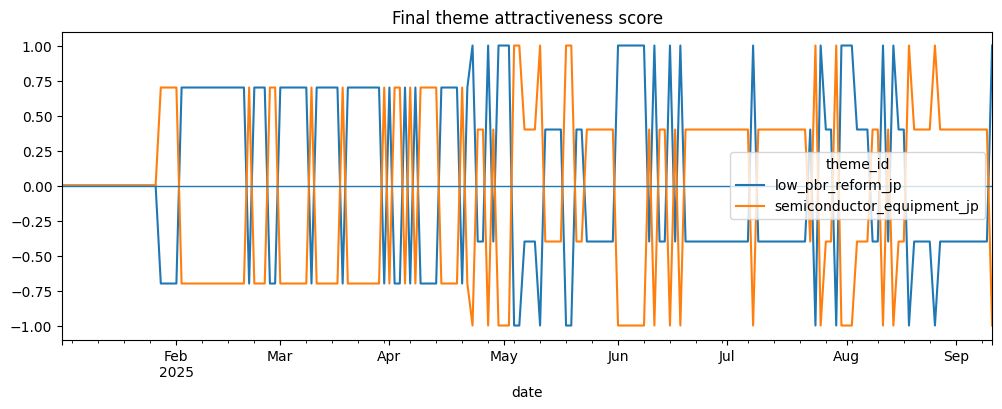

In [14]:
# Score history plot.
plot_df = score_panel.pivot(index='date', columns='theme_id', values='final_score')
ax = plot_df.plot(figsize=(12, 4), title='Final theme attractiveness score')
ax.axhline(0, linewidth=1)
plt.show()

## 7. テーマ配分最適化

ここでは long-only のテーマ配分を例示します。目的関数は以下です。

\[
\max_w \quad \mu^\top w - \lambda w^\top\Sigma w - c \| w - w_{prev}\|_1
\]

`mu` には `final_score` をスケール変換したものを使い、`Sigma` は rolling のテーマリターン共分散を使います。実運用では、テーマ間構成銘柄重複やファクターエクスポージャー制約もこの目的関数または制約に追加してください。

In [15]:
# ============================================================
# 10. Overlap matrix and portfolio optimization
# ============================================================
def holdings_overlap_matrix(holdings_df: pd.DataFrame, theme_ids: List[str]) -> pd.DataFrame:
    # Holding overlap = sum_i min(w_i,k, w_i,l) over common tickers.
    pivot = holdings_df.pivot_table(index='ticker', columns='theme_id', values='weight', aggfunc='sum').fillna(0.0)
    pivot = pivot.reindex(columns=theme_ids, fill_value=0.0)
    O = pd.DataFrame(np.eye(len(theme_ids)), index=theme_ids, columns=theme_ids, dtype=float)
    for a in theme_ids:
        for b in theme_ids:
            O.loc[a, b] = float(np.minimum(pivot[a], pivot[b]).sum())
    return O


def estimate_covariance_for_date(
    returns_wide: pd.DataFrame,
    dt: pd.Timestamp,
    theme_ids: List[str],
    lookback: int = 60,
    shrink: float = 0.10,
) -> np.ndarray:
    hist = returns_wide.loc[returns_wide.index <= dt, theme_ids].tail(lookback)
    if len(hist) < 10:
        vol = np.nanstd(returns_wide[theme_ids].values, axis=0)
        vol = np.where(np.isfinite(vol) & (vol > 1e-6), vol, 0.01)
        return np.diag(vol ** 2)
    cov = np.cov(hist.fillna(0.0).values.T)
    if cov.ndim == 0:
        cov = np.array([[float(cov)]])
    diag = np.diag(np.diag(cov))
    cov = (1 - shrink) * cov + shrink * diag
    cov = cov + 1e-8 * np.eye(len(theme_ids))
    return cov


def optimize_long_only_weights(
    scores: np.ndarray,
    cov: np.ndarray,
    prev_w: Optional[np.ndarray] = None,
    max_weight: float = 0.70,
    risk_aversion: float = 8.0,
    turnover_cost: float = 0.0015,
    score_scale: float = 0.0030,
) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    n = len(scores)
    if prev_w is None:
        prev_w = np.ones(n) / n
    prev_w = np.asarray(prev_w, dtype=float)
    if not np.isfinite(scores).any():
        return prev_w / prev_w.sum()
    scores = np.nan_to_num(scores, nan=0.0)
    mu = score_scale * scores
    max_weight = max(max_weight, 1.0 / n)

    if SCIPY_AVAILABLE:
        def obj(w):
            return -float(mu @ w - risk_aversion * (w @ cov @ w) - turnover_cost * np.abs(w - prev_w).sum())
        cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
        bounds = [(0.0, max_weight) for _ in range(n)]
        x0 = np.clip(prev_w, 0, max_weight)
        x0 = x0 / x0.sum() if x0.sum() > 0 else np.ones(n) / n
        res = minimize(obj, x0, method='SLSQP', bounds=bounds, constraints=cons, options={'maxiter': 200, 'ftol': 1e-10})
        if res.success and np.isfinite(res.x).all():
            w = np.clip(res.x, 0, max_weight)
            return w / w.sum()

    # Fallback: risk-adjusted softmax with cap.
    vol = np.sqrt(np.maximum(np.diag(cov), 1e-8))
    raw = np.exp(scores / 1.25) / np.maximum(vol, 1e-4)
    w = raw / raw.sum()
    for _ in range(10):
        over = w > max_weight
        if not over.any():
            break
        excess = (w[over] - max_weight).sum()
        w[over] = max_weight
        if (~over).any():
            w[~over] += excess * w[~over] / w[~over].sum()
    return w / w.sum()


def build_portfolio_weights(
    score_panel: pd.DataFrame,
    theme_returns_df: pd.DataFrame,
    holdings_df: pd.DataFrame,
    max_weight: float = 0.70,
    lookback_cov: int = 60,
) -> pd.DataFrame:
    theme_ids = sorted(score_panel['theme_id'].unique())
    ret_wide = theme_returns_df.pivot(index='date', columns='theme_id', values='ret').sort_index().reindex(columns=theme_ids)
    O = holdings_overlap_matrix(holdings_df, theme_ids)
    rows = []
    prev_w = np.ones(len(theme_ids)) / len(theme_ids)
    for dt, g in score_panel.sort_values('date').groupby('date'):
        g = g.set_index('theme_id').reindex(theme_ids)
        scores = g['final_score'].fillna(0.0).values
        cov = estimate_covariance_for_date(ret_wide, pd.Timestamp(dt), theme_ids, lookback=lookback_cov)
        # Add simple overlap penalty as covariance inflation.
        overlap = O.values
        cov_adj = cov + 0.00005 * np.maximum(overlap - np.eye(len(theme_ids)), 0.0)
        w = optimize_long_only_weights(scores, cov_adj, prev_w=prev_w, max_weight=max_weight)
        for tid, wi, sc in zip(theme_ids, w, scores):
            rows.append({'date': dt, 'theme_id': tid, 'weight': wi, 'score': sc})
        prev_w = w
    return pd.DataFrame(rows)


weights_df = build_portfolio_weights(score_panel, theme_returns_df, holdings_df, max_weight=0.70)
weights_df.tail(8)

,date,theme_id,weight,score
352,2025-09-05,low_pbr_reform_jp,0.3,-0.4
353,2025-09-05,semiconductor_equipment_jp,0.7,0.4
354,2025-09-08,low_pbr_reform_jp,0.3,-0.4
355,2025-09-08,semiconductor_equipment_jp,0.7,0.4
356,2025-09-09,low_pbr_reform_jp,0.3,-0.4
357,2025-09-09,semiconductor_equipment_jp,0.7,0.4
358,2025-09-10,low_pbr_reform_jp,0.7,1.0
359,2025-09-10,semiconductor_equipment_jp,0.3,-1.0


In [16]:
# ============================================================
# 11. Backtest utilities
# ============================================================
def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())


def perf_summary(ret: pd.Series, name: str = 'strategy') -> Dict[str, float]:
    ret = ret.dropna()
    if len(ret) == 0:
        return {'name': name, 'ann_return': np.nan, 'ann_vol': np.nan, 'sharpe': np.nan, 'max_drawdown': np.nan}
    ann_return = float((1 + ret).prod() ** (252 / len(ret)) - 1)
    ann_vol = float(ret.std(ddof=0) * np.sqrt(252))
    sharpe = float(ann_return / ann_vol) if ann_vol > 1e-12 else np.nan
    equity = (1 + ret).cumprod()
    return {'name': name, 'ann_return': ann_return, 'ann_vol': ann_vol, 'sharpe': sharpe, 'max_drawdown': max_drawdown(equity)}


def run_backtest(weights_df: pd.DataFrame, theme_returns_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    theme_ids = sorted(weights_df['theme_id'].unique())
    W = weights_df.pivot(index='date', columns='theme_id', values='weight').sort_index().reindex(columns=theme_ids).fillna(0.0)
    R = theme_returns_df.pivot(index='date', columns='theme_id', values='ret').sort_index().reindex(columns=theme_ids).fillna(0.0)
    # Weight decided at close t is applied to return on t+1.
    strat_ret = (W * R.shift(-1)).sum(axis=1).dropna()
    ew = pd.DataFrame(1.0 / len(theme_ids), index=W.index, columns=theme_ids)
    ew_ret = (ew * R.shift(-1)).sum(axis=1).dropna()
    out = pd.DataFrame({'strategy': strat_ret, 'equal_weight': ew_ret}).dropna()
    out['strategy_equity'] = (1 + out['strategy']).cumprod()
    out['equal_weight_equity'] = (1 + out['equal_weight']).cumprod()
    turnover = W.diff().abs().sum(axis=1).fillna(0.0)
    turnover.name = 'turnover'
    perf = pd.DataFrame([
        perf_summary(out['strategy'], 'strategy'),
        perf_summary(out['equal_weight'], 'equal_weight'),
    ])
    perf['avg_daily_turnover'] = [float(turnover.mean()), 0.0]
    return out.join(turnover, how='left'), perf

backtest_df, perf_df = run_backtest(weights_df, theme_returns_df)
perf_df.round(4)

,name,ann_return,ann_vol,sharpe,max_drawdown,avg_daily_turnover
0,strategy,-0.1305,0.1703,-0.7666,-0.2222,0.1222
1,equal_weight,-0.1025,0.1719,-0.5964,-0.2063,0.0000


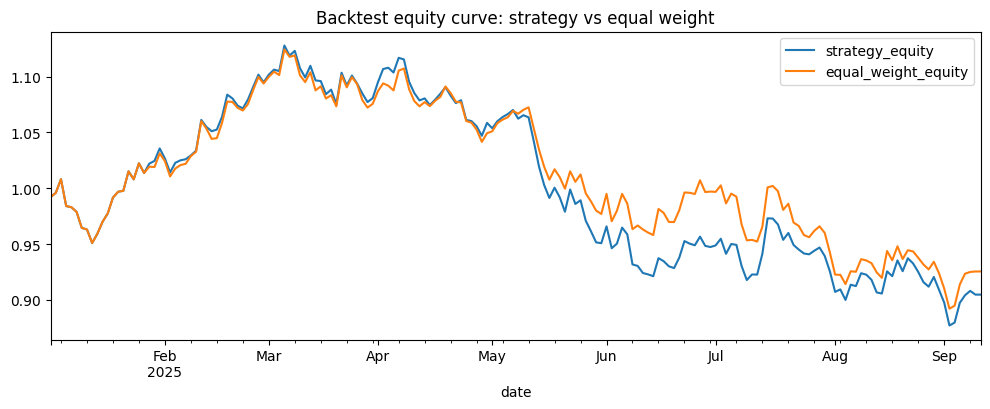

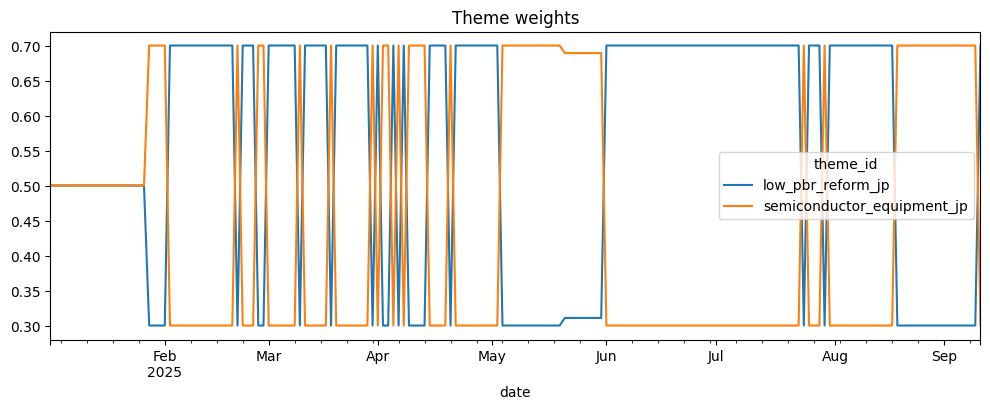

In [17]:
ax = backtest_df[['strategy_equity', 'equal_weight_equity']].plot(figsize=(12, 4), title='Backtest equity curve: strategy vs equal weight')
plt.show()

weight_plot = weights_df.pivot(index='date', columns='theme_id', values='weight')
ax = weight_plot.plot(figsize=(12, 4), title='Theme weights')
plt.show()

## 8. 最新ランキング、寄与分解、CSV 出力

以下は、運用時に日次レポートとして使う想定の出力です。

In [18]:
# ============================================================
# 12. Daily report tables
# ============================================================
def latest_theme_report(score_panel: pd.DataFrame, weights_df: pd.DataFrame, theme_df: pd.DataFrame, latest_date: Optional[pd.Timestamp] = None) -> pd.DataFrame:
    if latest_date is None:
        latest_date = score_panel['date'].max()
    base = score_panel[score_panel['date'] == latest_date].copy()
    w = weights_df[weights_df['date'] == latest_date][['theme_id', 'weight']]
    rep = base.merge(w, on='theme_id', how='left').merge(theme_df[['theme_id','theme_name_ja','theme_type']], on='theme_id', how='left')
    cols = [
        'date','theme_id','theme_name_ja','theme_type','rank','weight','final_score','rule_score_cs','ml_score_cs',
        'driver_signal_ewm_z','attention_z','breadth_ewm_z','novelty_z','underreaction','coherence_z',
        'valuation_crowding_penalty_z','risk_penalty_z','resid_mom_5_z','resid_vol_20_z'
    ]
    return rep[cols].sort_values('rank').round(4)

latest_report = latest_theme_report(score_panel, weights_df, theme_df)
latest_report

,date,theme_id,theme_name_ja,theme_type,rank,weight,final_score,rule_score_cs,ml_score_cs,driver_signal_ewm_z,attention_z,breadth_ewm_z,novelty_z,underreaction,coherence_z,valuation_crowding_penalty_z,risk_penalty_z,resid_mom_5_z,resid_vol_20_z
0,2025-09-10,low_pbr_reform_jp,低PBR・資本効率改革,style_theme,1.0,0.7,1.0,1.0,1.0,-0.8872,1.3279,1.3544,0.0000,-2.3671,0.8667,-1.2069,-0.2294,2.4665,1.2765
1,2025-09-10,semiconductor_equipment_jp,半導体製造装置,industry_theme,2.0,0.3,-1.0,-1.0,-1.0,0.7641,-0.9263,1.1731,-0.1302,0.3861,-1.8763,1.0849,-0.1787,0.6300,-0.2081


In [19]:
# Top recent news supporting each theme score.
recent_cutoff = news_scored_df['date'].max() - pd.tseries.offsets.BDay(10)
recent_news_report = article_theme_scores[article_theme_scores['date'] >= recent_cutoff].copy()
recent_news_report['abs_driver_signal'] = recent_news_report['driver_signal'].abs()
recent_news_report = recent_news_report.sort_values(['theme_id', 'abs_driver_signal'], ascending=[True, False]).groupby('theme_id').head(5)
recent_news_report[['date','theme_id','relevance','driver_signal','novelty','top_driver','headline','matched_tickers']].sort_values(['theme_id','date'], ascending=[True, False])

,date,theme_id,relevance,driver_signal,novelty,top_driver,headline,matched_tickers
288,2025-09-10,low_pbr_reform_jp,0.723447,0.103146,3.441691e-15,"株主還元強化, 資本効率改革",三菱商事、政策保有株の売却と株主還元方針を更新,[8058.T]
279,2025-09-05,low_pbr_reform_jp,0.647988,0.291229,5.107026e-15,"株主還元強化, 資本効率改革",アクティビスト保有判明、低PBR企業に株主還元強化圧力,[]
281,2025-09-05,low_pbr_reform_jp,0.407877,-0.207221,2.775558e-15,"株主還元強化, 資本効率改革",低PBR企業の公募増資発表に失望売り,[]
277,2025-09-05,low_pbr_reform_jp,0.091999,0.090586,-2.220446e-15,"株主還元強化, 資本効率改革",大手ファウンドリーが先端プロセスの設備投資増額を発表,[]
271,2025-08-28,low_pbr_reform_jp,0.091999,0.090586,-2.220446e-15,"株主還元強化, 資本効率改革",大手ファウンドリーが先端プロセスの設備投資増額を発表,[]
285,2025-09-09,semiconductor_equipment_jp,0.704002,0.537096,-3.552714e-15,"AI半導体需要, 半導体設備投資サイクル",アドバンテスト、GPU需要を背景に検査装置の上方修正観測,[6857.T]
278,2025-09-05,semiconductor_equipment_jp,0.892647,0.726786,-2.220446e-15,"AI半導体需要, 半導体設備投資サイクル",大手ファウンドリーが先端プロセスの設備投資増額を発表,[]
275,2025-09-02,semiconductor_equipment_jp,0.463155,0.384158,3.330669e-16,"AI半導体需要, 半導体設備投資サイクル",東京エレクトロン、AI半導体向け製造装置の受注回復を示唆,[8035.T]
272,2025-08-28,semiconductor_equipment_jp,0.892647,0.726786,-2.220446e-15,"AI半導体需要, 半導体設備投資サイクル",大手ファウンドリーが先端プロセスの設備投資増額を発表,[]
270,2025-08-27,semiconductor_equipment_jp,0.704002,0.537096,-3.552714e-15,"AI半導体需要, 半導体設備投資サイクル",アドバンテスト、GPU需要を背景に検査装置の上方修正観測,[6857.T]


In [20]:
# Export results.
OUT_DIR = Path('theme_model_outputs')
OUT_DIR.mkdir(exist_ok=True)

score_panel.to_csv(OUT_DIR / 'theme_score_panel.csv', index=False, encoding='utf-8-sig')
weights_df.to_csv(OUT_DIR / 'theme_weights.csv', index=False, encoding='utf-8-sig')
backtest_df.to_csv(OUT_DIR / 'theme_backtest.csv', index=True, encoding='utf-8-sig')
latest_report.to_csv(OUT_DIR / 'latest_theme_report.csv', index=False, encoding='utf-8-sig')
recent_news_report.to_csv(OUT_DIR / 'recent_news_report.csv', index=False, encoding='utf-8-sig')

print(f'Exported CSV files to: {OUT_DIR.resolve()}')

Exported CSV files to: /mnt/data/theme_model_outputs


## 9. 実データ投入時の差し替えポイント

このノートブックを本番データに接続する場合は、以下のように差し替えてください。

```python
# 1. ニュース
news_df = pd.read_csv('news.csv', parse_dates=['date'])
# 必須列: date, headline, body, source_type

# 2. 構成銘柄・ウェイト
holdings_df = pd.read_csv('theme_holdings.csv')
# 必須列: theme_id, ticker, weight
# 推奨列: company_name_ja, company_name_en, aliases

# 3. テーマバスケットリターン
theme_returns_df = pd.read_csv('theme_returns.csv', parse_dates=['date'])
# 必須列: date, theme_id, ret

# 4. ファクターリターン
factor_returns_df = pd.read_csv('factor_returns.csv', parse_dates=['date'])
# 必須列: date + factor columns

# 5. バリュエーション・混雑
valuation_df = pd.read_csv('theme_valuation_crowding.csv', parse_dates=['date'])
# 必須列: date, theme_id, valuation_penalty, crowding_penalty
```

その後、以下の主要関数を同じ順序で実行します。

```python
article_driver_scores, news_scored_df = classify_news_to_theme_drivers(news_df, theme_df, driver_df, holdings_df)
daily_features, article_theme_scores = aggregate_daily_theme_features(article_driver_scores, news_scored_df, theme_df, holdings_df)
panel = add_price_and_risk_features(daily_features, theme_returns_df, factor_returns_df, constituent_returns_df, valuation_df)
score_panel = add_forward_return_target(panel, horizon=20)
score_panel = add_rule_score(score_panel)
score_panel = walkforward_ml_score(score_panel, feature_cols, 'target_fwd_20d_resid')
weights_df = build_portfolio_weights(score_panel, theme_returns_df, holdings_df)
backtest_df, perf_df = run_backtest(weights_df, theme_returns_df)
```

本番運用では、YAML・構成銘柄・ニュース・価格・ファクターがすべて point-in-time であること、転載ニュースの重複除去、ニュース時刻と取引時刻の整合、複数検定・過学習管理を必ず確認してください。